In [ ]:
# Zachary Katz
# zachary_katz@mines.edu
# 25 March 2026


"""
SWOT Harmonic Analysis over ice shelves

Download selected SWOT data and load for two passes.
Advect based on Measures ice velocity map
Compute harmonic analysis, removing outliers
Calculate difference from CATS and plot.
"""

# Extensions and imports
%load_ext autoreload
%autoreload 2

import util.coordinate_transforms as transforms
import shapefile
import shapely
import earthaccess
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from datetime import datetime
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree

from pyproj import CRS, Transformer

import rasterio

import re
from collections import defaultdict
from pathlib import Path
import pyTMD
from cmap import Colormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib as mpl

# Paths
data_dir = "../_data/SWOT"


vel_path = "/mnt/c/users/ZacharyKatz/Desktop/Research/Background/antarctica_ice_velocity_450m_v2.nc"  # Path to velocity field
vel_mag_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/antarctic_ice_vel_phase_map_v01-vmag.nc"  # Path to velocity magnitude
moa_path = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/moa750_2009_hp1_v1.1.tif"  # Path to MOA
# RINGS Grounding Line Paths
rings_grounded_path = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp"
rings_coastline_path = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_coastline_2022.shp"
rings_grounded_path = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp"
rings_iceshelves_path = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_iceshelves_2022.shp"
rings_islands_ADD = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_islands_ADD.shp"
rings_polygonmask = "/mnt/c/users/zacharykatz/Desktop/Research/Background/RINGS_2022/RINGS_polygonmask.shp"

In [2]:
# Load grounding lines
paths = [
    rings_coastline_path,
    rings_grounded_path,
    rings_iceshelves_path,
    rings_islands_ADD,
    rings_polygonmask,
]

records_full = []
shapes_full = []
field_names_full = []

for path in paths:
    sf = shapefile.Reader(path)
    records_full.append(sf.records())
    shapes_full.append(sf.shapes())
    field_names_full.append([f[0] for f in sf.fields[1:]])

ice_shelf_polygons = []
grounded_polygons = []

sf = shapefile.Reader(rings_iceshelves_path)
fields = sf.fields[1:]  # Skip deletion flag
field_names = [field[0] for field in fields]

records = sf.records()
shapes = sf.shapes()

for record, shape in zip(records, shapes):
    rec_dict = dict(zip(field_names, record))
    classification = rec_dict["Type"]
    points = shape.points
    parts = list(shape.parts)
    parts.append(len(points))  # Append the end index of the last part
    for i in range(len(parts) - 1):
        part = points[parts[i] : parts[i + 1]]
        polygon = shapely.Polygon(part)
        if (
            classification == "Isolated island"
            or classification == "Ice rise or connected island"
            or classification == "Grounded ice or land"
        ):
            if polygon.is_valid:
                grounded_polygons.append(polygon)
        elif classification == "Ice shelf":
            if polygon.is_valid:
                ice_shelf_polygons.append(polygon)
        else:
            print(f"Unknown classification: {classification}")


def plot_RINGS_shapefile(
    records_list: list[shapefile._Record],
    shapes_list: list[shapefile.Shape],
    field_names_list: list[str],
    ax,
    colors: list[str],
    transform,
    fill: bool = False,
    zorder: int = 2,
    linewidth: int = 2,
) -> None:
    """
    Plots the given records and shapes on axis ax.

    Example usage:

    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
        transform=ps71_projection, fill=True, zorder=2, linewidth=1)

    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
        transform=ps71_projection, fill=False, zorder=2, linewidth=1)

    Parameters
    ----------
    records : list[shapefile._Record]
        Shapely record containing shape classification
    shapes : list[shapefile.Shape]
        Shapely shape points
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to polot on
    colors : list[str]
       [Grounded ice color, Ice Shelf color]; Must be length 2
    """
    for records, shapes, field_names in zip(
        records_list, shapes_list, field_names_list
    ):
        for record, shape in zip(records, shapes):
            rec_dict = dict(zip(field_names, record))
            classification = rec_dict["Type"]
            points = shape.points
            parts = list(shape.parts)
            parts.append(
                len(points)
            )  # Append the end index of the last part of the shapefile
            for i in range(len(parts) - 1):
                part = points[parts[i] : parts[i + 1]]
                if classification == "Coastline":
                    if fill:
                        ax.fill(
                            *zip(*part),
                            color=colors[1],
                            zorder=zorder,
                            transform=transform,
                        )
                    else:
                        ax.plot(
                            *zip(*part),
                            color=colors[1],
                            linewidth=linewidth,
                            zorder=zorder,
                            transform=transform,
                        )
                elif classification == "Grounded":
                    if fill:
                        ax.fill(
                            *zip(*part),
                            color=colors[0],
                            zorder=zorder,
                            transform=transform,
                        )
                    else:
                        ax.plot(
                            *zip(*part),
                            color=colors[0],
                            linewidth=linewidth,
                            zorder=zorder,
                            transform=transform,
                        )
                elif classification == "Transient":
                    if fill:
                        ax.fill(
                            *zip(*part),
                            color=colors[0],
                            zorder=zorder,
                            transform=transform,
                        )
                    else:
                        ax.plot(
                            *zip(*part),
                            color=colors[0],
                            linewidth=linewidth,
                            zorder=zorder,
                            transform=transform,
                        )
                elif classification == "Island":
                    if fill:
                        ax.fill(
                            *zip(*part),
                            color=colors[0],
                            zorder=zorder,
                            transform=transform,
                        )
                    else:
                        ax.plot(
                            *zip(*part),
                            color=colors[0],
                            linewidth=linewidth,
                            zorder=zorder,
                            transform=transform,
                        )
                else:
                    # print(f"Unknown classification: {classification}")
                    continue


with rasterio.open(moa_path) as moa:
    bounds = moa.bounds
    left, bottom, right, top = bounds.left, bounds.bottom, bounds.right, bounds.top
    moa_dat = moa.read(1)

ext = (left, right, bottom, top)

vel_mag = xr.open_dataarray(vel_mag_path)
bbox = [1500000, 590000, 2420000, 850000]  # Amery + some

vel_mag_sliced = vel_mag.sel(x=slice(1300000, 2800000), y=slice(900000, 390000))

velocity = xr.open_dataset(vel_path)
off = 100000
bbox = [1500000, 590000, 2420000, 850000]  # Amery + some
cropped_vel = velocity.sel(
    x=slice(bbox[0] - off, bbox[2] + off), y=slice(bbox[3] + off, bbox[1] - off)
)


def prep_velocity_interpolators(
    vel,
):  # Create interpolators at any point for quick querying
    vx_interp = RegularGridInterpolator(
        (vel.y.values[::-1], vel.x.values),
        vel["VX"].values[::-1, :],
        bounds_error=False,
        fill_value=np.nan,
    )
    vy_interp = RegularGridInterpolator(
        (vel.y.values[::-1], vel.x.values),
        vel["VY"].values[::-1, :],
        bounds_error=False,
        fill_value=np.nan,
    )
    return vx_interp, vy_interp

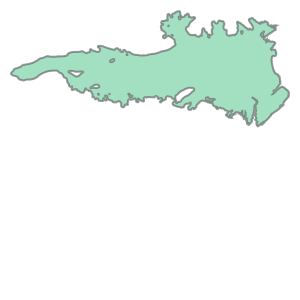

In [3]:
bbox_filter = [2000000, 650000, 2000001, 650001]
filtered_records_main = []
filtered_shapes_main = []
for record, _shape in zip(records, shapes):
    shape_bbox = _shape.bbox
    # Checks if any part of the shape is within the bounding box
    if (
        shape_bbox[0] < bbox_filter[2]
        and shape_bbox[2] > bbox_filter[0]
        and shape_bbox[1] < bbox_filter[3]
        and shape_bbox[3] > bbox_filter[1]
    ):
        filtered_records_main.append(record)
        filtered_shapes_main.append(_shape)
main_shapefile = shapely.geometry.shape(filtered_shapes_main[0].__geo_interface__)

main_shapefile

In [3]:
# Dowload SWOT if necessary
amery_bbox = [1500000, 590000, 2480000, 850000]
amery_xy = [
    (amery_bbox[0], amery_bbox[1]),  # xmin, ymin
    (amery_bbox[2], amery_bbox[1]),  # xmax, ymin
    (amery_bbox[2], amery_bbox[3]),  # xmax, ymax
    (amery_bbox[0], amery_bbox[3]),  # xmin, ymax
]

amery_ll = [transforms.xy2ll(x, y) for x, y in amery_xy]
lons, lats = zip(*amery_ll)
amery_ll_bbox = [min(lons), min(lats), max(lons), max(lats)]
amery_ll_bbox = tuple(v for v in amery_ll_bbox)


for track in ["271", "299", "327", "577"]:
    karin_results = earthaccess.search_data(
        short_name="SWOT_L2_HR_Raster_D",
        temporal=("2020-01-01", "2030-01-01"),
        granule_name=f"*100m*x_*_{track}_0??F*.nc",
        bounding_box=amery_ll_bbox,
    )
    earthaccess.download(karin_results, f"{data_dir}/SWOT_{track}", provider="POCLOUD")

QUEUEING TASKS | :   0%|          | 0/70 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/70 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/70 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/121 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/121 [00:00<?, ?it/s]

...

PROCESSING TASKS | :   0%|          | 0/33 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/33 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/44 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/44 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/44 [00:00<?, ?it/s]

In [4]:
# Load rasters, get latest version, and select specific rasters to keep

rasters = list(Path(data_dir).rglob("SWOT_L2_HR_Raster*PID0_??.nc"))
print(f"Found {len(rasters)} rasters")

latest = defaultdict(lambda: (None, -1))

for f in rasters:
    match = re.search(r"(.*)_PID0_(\d+)\.nc$", f.name)
    if match:
        base, version = match.groups()
        version = int(version)
        if version > latest[base][1]:
            latest[base] = (f, version)

# Collect just the paths
rasters = [val[0] for val in latest.values()]

# Only keep rasters based on track number, etc.
swot_rasters = [f for f in rasters if ("_271_014F" in f.name)]
# Sort by granule number, then cycle number
swot_rasters.sort(
    key=lambda f: (
        re.search(r"_x_(\d+)_", f.name).group(1),
        re.search(r"_0(\d{2})F", f.name).group(1),
    )
)
print(f"Keeping {len(swot_rasters)} rasters")
for raster in swot_rasters:
    print(raster)

Found 224 rasters
Keeping 10 rasters
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_032_271_014F_20250507T162617_20250507T162638_PID0_04.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_033_271_014F_20250528T131123_20250528T131145_PID0_02.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_034_271_014F_20250618T095627_20250618T095648_PID0_01.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_035_271_014F_20250709T064134_20250709T064156_PID0_01.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_036_271_014F_20250730T032639_20250730T032700_PID0_02.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_037_271_014F_20250820T001144_20250820T001205_PID0_01.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_038_271_014F_20250909T205647_20250909T205708_PID0_01.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_039_271_014F_20250930T174151_20250930T174212_PID0_01.nc
../_data/SWOT/SWOT_271/SWOT

In [5]:
# Advect chosen rasters to common reference time using using vel grid
# Reference time is approx mean of raster times based on names, to minimize advection errors

raster_times = []
for r in swot_rasters:
    matches = re.findall(r"(\d{8}T\d{6})", r.name)
    assert len(matches) > 0, f"No timestamp found in raster name: {r.name}"
    match = matches[0]
    raster_time = datetime.strptime(match, "%Y%m%dT%H%M%S")
    raster_times.append(raster_time)

mean_timestamp = sum(dt.timestamp() for dt in raster_times) / len(raster_times)
mean_date = datetime.fromtimestamp(mean_timestamp)

# Advect raster positions x,y to mean_date
vx_interp, vy_interp = prep_velocity_interpolators(cropped_vel)
delta_t = 10  # Days
DAY_TO_YEAR = 365.25
DAY_TO_SECONDS = 24 * 3600
multiplier = delta_t / DAY_TO_YEAR

crs_ps = CRS.from_epsg(3031)
for raster in swot_rasters[:]:
    ds = xr.open_dataset(raster, decode_times=False)
    raster_time = datetime.strptime(ds.time_granule_start, "%Y-%m-%dT%H:%M:%S.%fZ")
    direction = 1 if raster_time < mean_date else -1
    timesteps = int(
        abs((mean_date - raster_time).total_seconds()) // (delta_t * DAY_TO_SECONDS)
    )

    # Get SWOT and velocity grid in PS71
    x = ds.x.values
    y = ds.y.values

    utm = ccrs.UTM(zone=ds.utm_zone_num, southern_hemisphere=True)
    epsg = utm.to_epsg()
    crs_utm = CRS.from_epsg(epsg)

    transformer = Transformer.from_crs(crs_utm, crs_ps, always_xy=True)
    X_utm, Y_utm = np.meshgrid(x, y)
    X, Y = transformer.transform(X_utm, Y_utm)

    ds["x_ps71"] = (("y", "x"), X.copy())
    ds["y_ps71"] = (("y", "x"), Y.copy())

    points = np.empty((X.size, 2), dtype=X.dtype)
    print(points.shape, mean_date, raster_time, direction, timesteps)

    # Advection loop
    for i in range(timesteps):
        points[:, 0] = Y.ravel()
        points[:, 1] = X.ravel()

        vx = vx_interp(points).reshape(X.shape)
        vy = vy_interp(points).reshape(Y.shape)

        valid = np.isfinite(vx) & np.isfinite(vy)
        X[valid] += direction * vx[valid] * multiplier
        Y[valid] += direction * vy[valid] * multiplier

    ds["x_adv"] = (("y", "x"), X)
    ds["y_adv"] = (("y", "x"), Y)

    # Save new advected raster
    output_raster = raster.with_name(raster.stem + "_adv.nc")
    ds.to_netcdf(output_raster)

(3198732, 2) 2025-08-22 02:16:13 2025-05-07 16:26:17.193815 1 10
(3198732, 2) 2025-08-22 02:16:13 2025-05-28 13:11:23.885393 1 8
(3198732, 2) 2025-08-22 02:16:13 2025-06-18 09:56:27.298181 1 6
(3198732, 2) 2025-08-22 02:16:13 2025-07-09 06:41:34.940686 1 4
(3198732, 2) 2025-08-22 02:16:13 2025-07-30 03:26:39.437803 1 2
(3198732, 2) 2025-08-22 02:16:13 2025-08-20 00:11:44.057367 1 0
(3198732, 2) 2025-08-22 02:16:13 2025-09-09 20:56:47.677144 -1 1
(3198732, 2) 2025-08-22 02:16:13 2025-09-30 17:41:51.728602 -1 3
(3198732, 2) 2025-08-22 02:16:13 2025-10-21 14:26:57.499430 -1 6
(3198732, 2) 2025-08-22 02:16:13 2026-03-16 15:42:31.059817 -1 20


In [4]:
# Load advected rasters, get latest version, and select specific rasters to keep
rasters = list(Path(data_dir).rglob("SWOT_L2_HR_Raster*_adv.nc"))
print(f"Found {len(rasters)} rasters")

# Only keep rasters based on track number, etc.
swot_rasters_adv = [
    f for f in rasters if ("_271_014" in f.name or "_299_014" in f.name)
]
# Sort by granule number, then cycle number
swot_rasters_adv.sort(
    key=lambda f: (
        re.search(r"_x_(\d+)_", f.name).group(1),
        re.search(r"_0(\d{2})F", f.name).group(1),
    )
)
print(f"Keeping {len(swot_rasters_adv)} rasters")
for raster in swot_rasters_adv:
    print(raster)

Found 123 rasters
Keeping 26 rasters
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_032_299_014F_20250508T162648_20250508T162709_PID0_02_adv.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_032_271_014F_20250507T162617_20250507T162638_PID0_04_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_033_299_014F_20250529T131155_20250529T131216_PID0_02_adv.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_033_271_014F_20250528T131123_20250528T131145_PID0_02_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_034_299_014F_20250619T095658_20250619T095719_PID0_01_adv.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_034_271_014F_20250618T095627_20250618T095648_PID0_01_adv.nc
../_data/SWOT/SWOT_299/SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_035_299_014F_20250710T064206_20250710T064227_PID0_01_adv.nc
../_data/SWOT/SWOT_271/SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_035_271_014F_20250709T064134_20250709T064156_PID0_01_ad

2
[475000. 475100. 475200. ... 654900. 655000. 655100.] [2133900. 2134000. 2134100. ... 2313800. 2313900. 2314000.]
[1946002.90100703 1946038.81649828 1946074.73767137 ... 2179486.79277549
 2179522.2980879  2179557.79908733] [605452.99642365 605488.39462891 605523.78522117 ... 838565.28011887
 838601.36799357 838637.47393834]
[341300. 341400. 341500. ... 519800. 519900. 520000.] [2134400. 2134500. 2134600. ... 2313000. 2313100. 2313200.]
[1981864.38372774 1981890.62203989 1981916.85885826 ... 2188693.73711674
 2188712.69319222              nan] [522780.57646734 522806.44940691 522832.29961988 ... 742479.30491058
 742505.76759591             nan]


ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

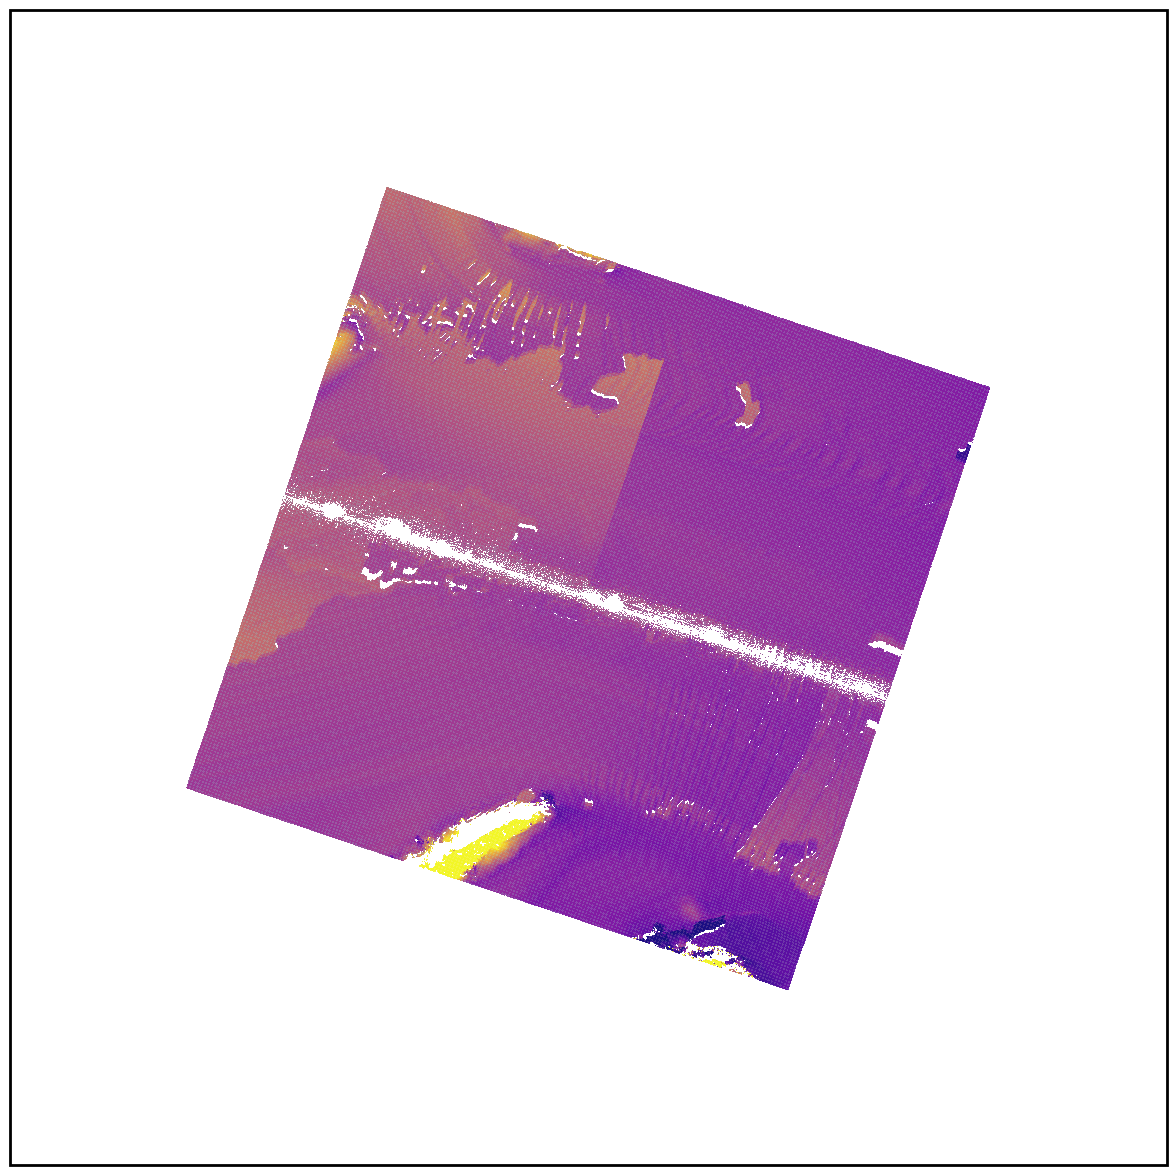

In [17]:
# Test plot of a few granules
to_plot = "wse"
label = "Elevation [m]"
vmin = 0
vmax = 200
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))

bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

# oslo = Colormap('crameri:oslo').to_matplotlib()
# ax.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)
# cb = ax.imshow(vel_mag_sliced, cmap=oslo,extent=[vel_mag_sliced['x'].min(), vel_mag_sliced['x'].max(),
#       vel_mag_sliced['y'].min(), vel_mag_sliced['y'].max()],origin='upper',alpha=0.6,vmin=0,vmax=1100)

# plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
#                    transform=ps71_projection, fill=False, zorder=2, linewidth=1)

test_plot = [r for r in swot_rasters_adv[:2]]
print(len(test_plot))
for raster in test_plot:
    ds = xr.open_mfdataset(
        raster, combine="nested", concat_dim="num_lines", decode_times=False
    )

    wse = ds[to_plot].isel(num_lines=0)
    utm = ccrs.UTM(zone=ds.utm_zone_num, southern_hemisphere=True)
    x = ds.x.values
    y = ds.y.values

    X_adv = ds["x_adv"].isel(num_lines=0)
    Y_adv = ds["y_adv"].isel(num_lines=0)
    print(np.unique(x), np.unique(y))
    print(np.unique(X_adv), np.unique(Y_adv))
    # Set nan to a value outside the range for better visualization
    mesh_adv = ax.pcolormesh(
        X_adv,
        Y_adv,
        wse.values,
        transform=ps71_projection,
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        alpha=0.6,
    )

    X = ds["x_ps71"].isel(num_lines=0)
    Y = ds["y_ps71"].isel(num_lines=0)
    mesh = ax.pcolormesh(
        X,
        Y,
        wse.values,
        transform=ps71_projection,
        cmap="plasma",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        alpha=0.6,
    )

    ds.close()

ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
fig.patch.set_alpha(0.0)
plt.draw()

In [5]:
# Pick primary raster to use as points for computation.
# Find points on any other raster closest to primary raster points, with max dist max_dist m

max_dist = 100  # Meters
primary_raster = swot_rasters_adv[0]


ds_primary = xr.open_mfdataset(
    primary_raster, combine="nested", concat_dim="num_lines", decode_times=False
)
primary_x = ds_primary["x_adv"].isel(num_lines=0).values
primary_y = ds_primary["y_adv"].isel(num_lines=0).values
primary_pts = np.column_stack([primary_x.ravel(), primary_y.ravel()])

mask = shapely.contains_xy(main_shapefile, primary_x, primary_y)

wse_primary = ds_primary["wse"].values
wse_primary_flat = wse_primary.ravel()

n_pts = primary_pts.shape[0]
wse_ts = np.full((n_pts, len(swot_rasters_adv)), np.nan)

time_ts = [ds_primary.time_granule_start]
wse_ts[:, 0] = wse_primary_flat
ny, nx = primary_x.shape

ds_primary.close()

other_rasters = [r for r in swot_rasters_adv if r != primary_raster]
for t, raster in enumerate(other_rasters, start=1):
    print(f"Processing {raster.name} ({t}/{len(other_rasters)})")
    ds_secondary = xr.open_mfdataset(
        raster, combine="nested", concat_dim="num_lines", decode_times=False
    )
    secondary_x = ds_secondary["x_adv"].isel(num_lines=0).values
    secondary_y = ds_secondary["y_adv"].isel(num_lines=0).values
    wse = ds_secondary["wse"].values
    wse_flat = wse.ravel()
    secondary_points = np.column_stack([secondary_x.ravel(), secondary_y.ravel()])

    time_ts.append(ds_secondary.time_granule_start)

    ds_secondary.close()

    # Make tree to query
    tree = cKDTree(secondary_points)
    dist, idx = tree.query(primary_pts, distance_upper_bound=max_dist)
    valid = dist != np.inf

    wse_ts[valid, t] = wse_flat[idx[valid]]


wse_ts = wse_ts.reshape(ny, nx, -1)  # (y, x, time)
wse_ts_masked = np.where(mask[:, :, None], wse_ts, np.nan)
ds_out = xr.Dataset(
    {"wse": (["y", "x", "time"], wse_ts_masked)},
    coords={
        "time": time_ts,
        "x": (["y", "x"], primary_x),
        "y": (["y", "x"], primary_y),
    },
)

Processing SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_032_271_014F_20250507T162617_20250507T162638_PID0_04_adv.nc (1/25)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_033_299_014F_20250529T131155_20250529T131216_PID0_02_adv.nc (2/25)
Processing SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_033_271_014F_20250528T131123_20250528T131145_PID0_02_adv.nc (3/25)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_034_299_014F_20250619T095658_20250619T095719_PID0_01_adv.nc (4/25)
Processing SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_034_271_014F_20250618T095627_20250618T095648_PID0_01_adv.nc (5/25)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_035_299_014F_20250710T064206_20250710T064227_PID0_01_adv.nc (6/25)
Processing SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_035_271_014F_20250709T064134_20250709T064156_PID0_01_adv.nc (7/25)
Processing SWOT_L2_HR_Raster_100m_UTM42D_N_x_x_x_036_299_014F_20250731T032710_20250731T032731_PID0_01_adv.nc (8/25)
Processing SWOT_L2_HR_Raster_100m_UTM43D_N_x_x_x_036_271_014F_20250730T0

(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)
(1802, 1802) (1802, 1802) (1802, 1802)


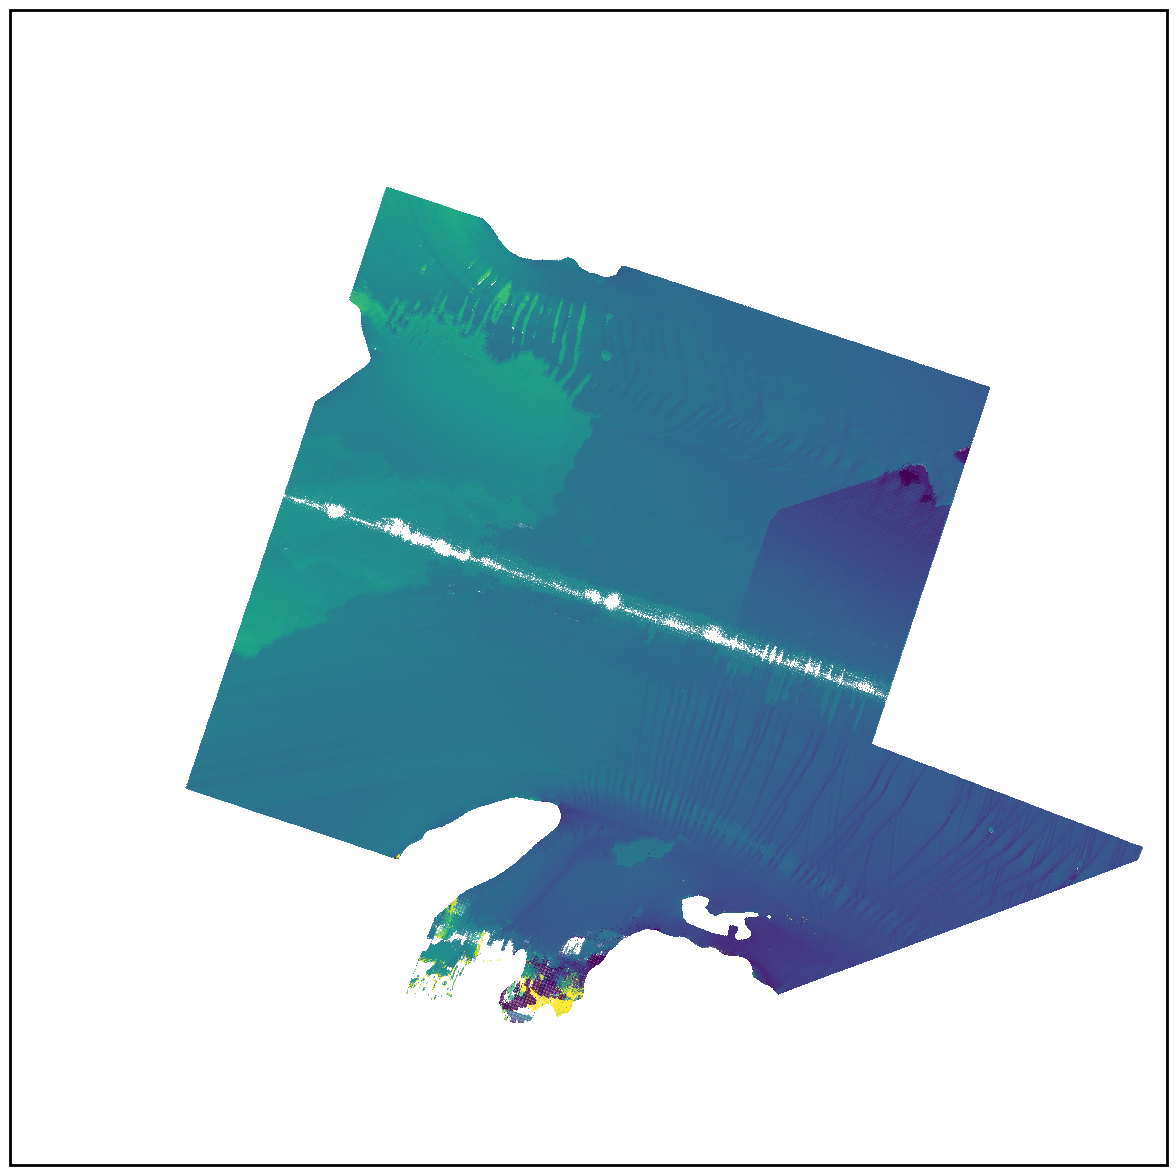

In [8]:
# Plot ds_out at each time step to verify
to_plot = "wse"
label = "Elevation [m]"
vmin = 0
vmax = 200
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))

bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

for i in range(12):
    wse = ds_out[to_plot][:, :, i]
    x = ds_out.x.values
    y = ds_out.y.values
    print(wse.shape, x.shape, y.shape)
    mesh_adv = ax.pcolormesh(
        x,
        y,
        wse.values,
        transform=ps71_projection,
        cmap="viridis",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        alpha=0.6,
    )

In [6]:
# Mask bad data points as nan

# For each point, find median value and mask values that are more than 2 m from median
wse = ds_out.wse.values  # (y, x, time)
median = np.nanmedian(wse, axis=2)  # (y, x)
diff = np.abs(wse - median[:, :, None])  # (y, x, time)
wse_masked = np.where(diff > 2, np.nan, wse)  # (y, x, time)
ds_out["wse_masked"] = (("y", "x", "time"), wse_masked)


# Remove points with less than 10 observations:
count = np.sum(~np.isnan(wse_masked), axis=2)  # (y, x)
wse_masked_two = np.where(count[:, :, None] < 20, np.nan, wse_masked)  # (y, x, time)
ds_out["wse_masked"] = (("y", "x", "time"), wse_masked_two)

/tmp/ipykernel_173729/1240979618.py:5: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(wse, axis=2)  # (y, x)


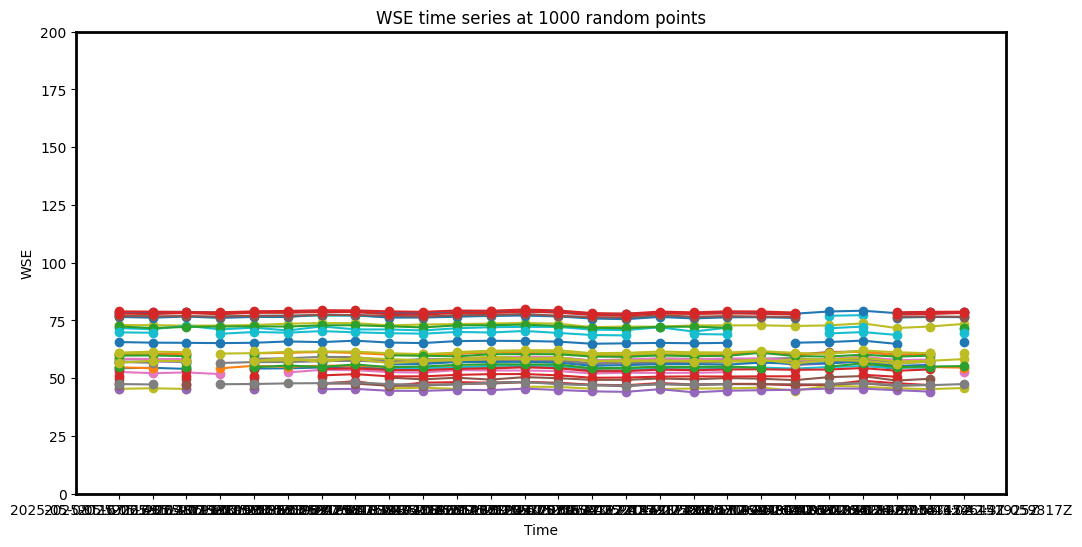

In [96]:
n_samples = 1000
rng = np.random.default_rng()
y_idx = rng.integers(0, ny, size=n_samples)
x_idx = rng.integers(0, nx, size=n_samples)

plt.figure(figsize=(12, 6))

# <al

for y, x in zip(y_idx, x_idx):
    plt.plot(
        time_ts, ds_out["wse_masked"][y, x, :], marker="o", label=f"Point ({y}, {x})"
    )

plt.xlabel("Time")
plt.ylabel("WSE")
plt.title(f"WSE time series at {n_samples} random points")
plt.ylim(0, 200)
plt.show()

In [7]:
# Harmonic analysis at each point
# Try sinusoid fit MATRIX

# Tidal constituents [hr]
HR_IN_DAY = 24
SEC_IN_HR = 3600

M2 = 12.4206012
S2 = 12
N2 = 12.65834751
K2 = 11.96723606

K1 = 23.9344721
O1 = 25.81933871
P1 = 24.06588766
Q1 = 26.868350

constituents = {
    "M2": M2,
    "S2": S2,
    "N2": N2,
    "K2": K2,
    "K1": K1,
    "O1": O1,
    "P1": P1,
    "Q1": Q1,
}


def tide_model(t, periods, parameters):
    """
    Generate the tide from synthetic data.

    Parameters
    ----------
    t : List
        List of sampling times in hours
    periods : dict
        Dictionary of tidal constituent periods in hours
    parameters : list
        List in form [A1, A2, ... , phi_1, phi_2, ...]
        where A is the amplitude in m and phi is the phase shift in radians

    Returns
    -------
    modeled : list
        Tides at time t as estimated by the model
    """
    assert len(parameters) == 2 * len(
        periods
    ), "Parameters must be twice the number of periods"

    model = np.zeros_like(t, dtype=float)
    n = len(periods)
    for i in range(n):
        A = parameters[i]
        phi = parameters[i + n]
        model += A * np.cos(2 * np.pi * t / periods[i] - phi)
    return model


def residuals(parameters, t, data, periods):
    """
    Residual function for scipy's least_squares
    Scipy does the squaring for us.
    """
    return tide_model(t, periods, parameters) - data


periods = [constituents[c] for c in constituents]

initial_guess = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
amp_grid = np.full((ny, nx, 8), np.nan)
ph_grid = np.full((ny, nx, 8), np.nan)

times = np.array(ds_out.time.values, dtype="datetime64[ns]")
t_hours = (times - times[0]) / np.timedelta64(1, "h")

periods = np.array([M2, S2, N2, K2, K1, O1, P1, Q1])
omega = 2 * np.pi / periods

# Design matrix
t_col = t_hours[:, None]  # (time, 1)

X = np.hstack([np.cos(t_col * omega), np.sin(t_col * omega)])

# This has lots of nans, need to mask
# Each row now has different shape...
wse_mskd = ds_out.wse_masked.values  # (y, x, time)

ny, nx, nt = wse_masked.shape

# reshape to (space, time)
Y = wse_mskd.reshape(ny * nx, nt).T  # (time, n_points)

/tmp/ipykernel_173729/690188545.py:76: UserWarning: no explicit representation of timezones available for np.datetime64
  times = np.array(ds_out.time.values, dtype="datetime64[ns]")


In [8]:
# FULL FIT
N = Y.shape[1]
T, K = X.shape
periods_to_fit = len(periods)
beta = np.full((K, N), np.nan)  # (params, pixels)

for i in range(N):
    y = Y[:, i]

    valid = np.isfinite(y)

    if np.sum(valid) < 20:
        continue

    Xi = X[valid, :]
    yi = y[valid]
    yi = yi - np.nanmean(yi)  # Demean for sinusoid fit [Could also detrend]

    beta[:, i], *_ = np.linalg.lstsq(Xi, yi, rcond=None)

A = beta[:periods_to_fit, :]
B = beta[periods_to_fit:, :]
amp = np.sqrt(A**2 + B**2)
phase = np.arctan2(-B, A)  # radians
phase_deg = np.degrees(phase) % 360

In [9]:
# Reshape back to grid with Nans for bad points
amp_grid = amp.T.reshape(ny, nx, periods_to_fit)
ph_grid = phase_deg.T.reshape(ny, nx, periods_to_fit)

ds_out["amp_fit"] = (("y", "x", "constituent"), amp_grid)
ds_out["ph_fit"] = (("y", "x", "constituent"), ph_grid)

(1802, 1802) (1802, 1802) (1802, 1802)


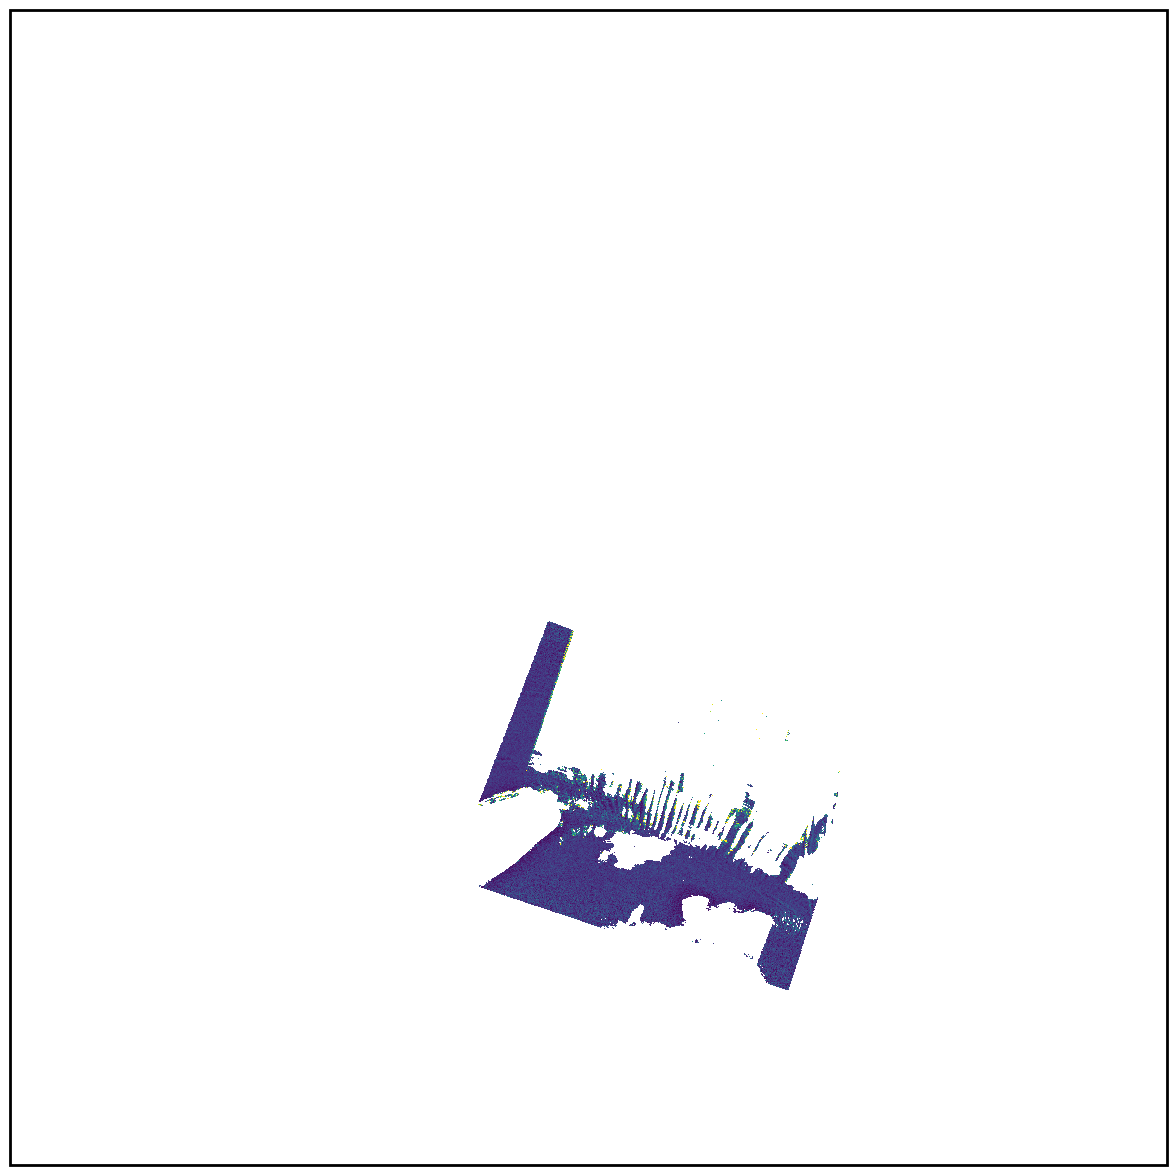

In [ ]:
# Plot Fitted Amp
to_plot = "amp_fit"
label = "Elevation [m]"
vmin = 0
vmax = 2
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))

bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

amp = ds_out[to_plot][:, :, 0]
x = ds_out.x.values
y = ds_out.y.values
print(amp.shape, x.shape, y.shape)
mesh_adv = ax.pcolormesh(
    x,
    y,
    amp.values,
    transform=ps71_projection,
    cmap="viridis",
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    alpha=1,
)

In [10]:
# Compute CATS at these points
model_loc = "/mnt/c/Users/ZacharyKatz/Desktop/Research/Background"
model = "CATS2008-v2023"

# Ravel and reshape after tide calculation
x_ravel = ds_out.x.values.ravel()
y_ravel = ds_out.y.values.ravel()

mask_flat = mask.ravel()
x_valid = x_ravel[mask_flat]
y_valid = y_ravel[mask_flat]


lons, lats = transforms.xy2ll(x_valid, y_valid)
tide_times = [
    datetime.strptime(time, "%Y-%m-%dT%H:%M:%S.%fZ") for time in ds_out.time.values
]

model = pyTMD.io.model(model_loc, format="netcdf").elevation(model)
constituents_pyTMD = pyTMD.io.OTIS.read_constants(
    model.grid_file,
    model.model_file,
    model.projection,
    type=model.type,
    grid=model.format,
)
c = constituents_pyTMD.fields

amp_pyTMD, ph_pyTMD, D = pyTMD.io.OTIS.interpolate_constants(
    np.atleast_1d(lons),
    np.atleast_1d(lats),
    constituents_pyTMD,
    type=model.type,
    method="spline",
    extrapolate=True,
)

amp_pyTMD = [ap[:8] for ap in amp_pyTMD]
ph_pyTMD = [p[:8] for p in ph_pyTMD]

n_const = 8
n_total = mask_flat.size
amp_full = np.full((n_total, n_const), np.nan)
ph_full = np.full((n_total, n_const), np.nan)

amp_full[mask_flat] = np.array(amp_pyTMD)
ph_full[mask_flat] = np.array(ph_pyTMD)

# Reshape back to grid and add to ds_out
amp_pyTMD_grid = np.array(amp_full).reshape(ny, nx, -1)
ph_pyTMD_grid = np.array(ph_full).reshape(ny, nx, -1)

ds_out["amp_pyTMD"] = (("y", "x", "constituent_pyTMD"), amp_pyTMD_grid[:, :, :8])
ds_out["ph_pyTMD"] = (("y", "x", "constituent_pyTMD"), ph_pyTMD_grid[:, :, :8])

In [ ]:
# Plot CATS at a few time steps to verify
to_plot = "amp_pyTMD"
label = "Elevation [m]"
vmin = 0
vmax = 1
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))

bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

wse = ds_out[to_plot][:, :, 1]
# wse = ds_out['wse'][:,:,1]
x = ds_out.x.values
y = ds_out.y.values
print(wse.shape, x.shape, y.shape)
mesh_adv = ax.pcolormesh(
    x,
    y,
    wse.values,
    transform=ps71_projection,
    cmap="viridis",
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    alpha=1,
)

wse = ds_out[to_plot][:, :, 1]
wse = ds_out["wse"][:, :, 1]
x = ds_out.x.values
y = ds_out.y.values
print(wse.shape, x.shape, y.shape)
mesh_adv = ax.pcolormesh(
    x,
    y,
    wse.values,
    transform=ps71_projection,
    cmap="viridis",
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    alpha=1,
)

In [ ]:
# Plot CATS - FIT difference for each constituent

# Determine which constitutents in pyTMD correspond to which in our fit based on period
periods_fit = np.array(periods)
periods_pyTMD = np.array([M2, S2, N2, K2, K1, O1, P1, Q1])

name_to_plot = "M2"
idx_fit = periods_fit == constituents[name_to_plot]
idx_pyTMD = periods_pyTMD == constituents[name_to_plot]
print(idx_fit, idx_pyTMD)
# Get number of index
idx_fit = np.where(idx_fit)[0][0]
idx_pyTMD = np.where(idx_pyTMD)[0][0]
print(idx_fit, idx_pyTMD)

[ True False False False False False False False] [ True False False False False False False False]
0 0


: 

In [ ]:
# Plot CATS Difference
label = "Fit - CATS [m]"

vmin = -0.75
vmax = 0.75
ps71_projection = ccrs.Stereographic(
    central_latitude=-90, central_longitude=0, true_scale_latitude=-71
)
crs_polar_stereo = CRS.from_epsg(3031)
fig, ax = plt.subplots(subplot_kw={"projection": ps71_projection}, figsize=(15, 15))


oslo = Colormap("crameri:oslo").to_matplotlib()
ax.imshow(moa_dat, extent=ext, cmap="gray", vmin=15000, vmax=17000)
cb = ax.imshow(
    vel_mag_sliced,
    cmap=oslo,
    extent=[
        vel_mag_sliced["x"].min(),
        vel_mag_sliced["x"].max(),
        vel_mag_sliced["y"].min(),
        vel_mag_sliced["y"].max(),
    ],
    origin="upper",
    alpha=0.6,
    vmin=0,
    vmax=1100,
)

plot_RINGS_shapefile(
    records_list=records_full,
    shapes_list=shapes_full,
    field_names_list=field_names_full,
    ax=ax,
    colors=["white", "None"],
    transform=ps71_projection,
    fill=False,
    zorder=2,
    linewidth=1,
)


bbox = [1673000, 590000, 2280000, 860000]  # Amery + some

diff = ds_out["amp_fit"][:, :, idx_fit] - ds_out["amp_pyTMD"][:, :, idx_pyTMD]


x = ds_out.x.values
y = ds_out.y.values
mesh_adv = ax.pcolormesh(
    x,
    y,
    diff.values,
    transform=ps71_projection,
    cmap="seismic",
    shading="auto",
    vmin=vmin,
    vmax=vmax,
    alpha=1,
)

# Color and scale bars
k_cbar_anchor = (0.001, 0.25)
cbbox = inset_axes(
    ax,
    width=5,
    height=1.2,
    bbox_to_anchor=k_cbar_anchor,
    bbox_transform=ax.transAxes,
    loc="lower left",
)
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis="both",
    left=False,
    top=False,
    right=False,
    bottom=False,
    labelleft=False,
    labeltop=False,
    labelright=False,
    labelbottom=False,
)
cbbox.set_facecolor([0, 0, 0, 0.8])

cbaxes = inset_axes(cbbox, "92%", "20%", loc="center")
cbar = fig.colorbar(
    mesh_adv, cax=cbaxes, orientation="horizontal", extend="both"
)  # make colorbar
cbar.outline.set_edgecolor("white")
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=24, color="white", labelcolor="white")
cbar.set_label(label, fontsize=28, color="white", labelpad=7)
cbar.ax.xaxis.set_label_position("top")

cbar.ax.minorticks_on()

cbar.ax.tick_params(which="minor", length=4, color="white")


v_cbar_anchor = (0.001, 0.001)
cbbox = inset_axes(
    ax,
    width=5,
    height=1.2,
    bbox_to_anchor=v_cbar_anchor,
    bbox_transform=ax.transAxes,
    loc="lower left",
)
[cbbox.spines[k].set_visible(False) for k in cbbox.spines]
cbbox.tick_params(
    axis="both",
    left=False,
    top=False,
    right=False,
    bottom=False,
    labelleft=False,
    labeltop=False,
    labelright=False,
    labelbottom=False,
)
cbbox.set_facecolor([0, 0, 0, 0.8])

cbaxes = inset_axes(cbbox, "92%", "20%", loc="center")
cbar = fig.colorbar(cb, cax=cbaxes, orientation="horizontal")  # make colorbar
cbar.outline.set_edgecolor("white")
cbar.outline.set_linewidth(1)
cbar.ax.tick_params(labelsize=24, color="white", labelcolor="white")
cbar.set_label("Ice Velocity [m/a]", fontsize=28, color="white", labelpad=7)
cbar.ax.xaxis.set_label_position("top")

cbar.ax.minorticks_on()

cbar.ax.tick_params(which="minor", length=4, color="white")

print("SCALEBAR AND INSET")
scalebar = AnchoredSizeBar(
    ax.transData,
    100000,
    "100 km",
    "lower left",
    pad=0.1,
    sep=1,
    color="white",
    frameon=False,
    size_vertical=5000,
    fontproperties=mpl.font_manager.FontProperties(size=30, weight="bold"),
    label_top=True,
)

ax.add_artist(scalebar)
scalebar.set_bbox_to_anchor((0.45, 0.001), transform=ax.transAxes)


# Add inset map using moa grounding lines
inset = fig.add_axes(
    [0.12, 0.47, 0.2, 0.2], projection=ps71_projection
)  # [left, bottom, width, height]
inset.patch.set_facecolor("none")
for spine in inset.spines.values():
    spine.set_visible(False)
inset.set_xticks([])
inset.set_yticks([])

plot_RINGS_shapefile(
    records_list=records_full,
    shapes_list=shapes_full,
    field_names_list=field_names_full,
    ax=inset,
    colors=["lightgray", "white"],
    transform=ps71_projection,
    fill=True,
    zorder=2,
    linewidth=1,
)


rect = plt.Rectangle(
    (
        bbox[0],
        bbox[1],
    ),
    bbox[2] - bbox[0],
    bbox[3] - bbox[1],
    zorder=3,
    linewidth=3,
    edgecolor="#CC4628",
    facecolor="none",
)
inset.add_patch(rect)


ax.set_xlim(bbox[0], bbox[2])
ax.set_ylim(bbox[1], bbox[3])
fig.patch.set_alpha(0.0)
plt.draw()

fig.savefig(f"{name_to_plot}_271_299.png", dpi=300, bbox_inches="tight", format="png")

SCALEBAR AND INSET


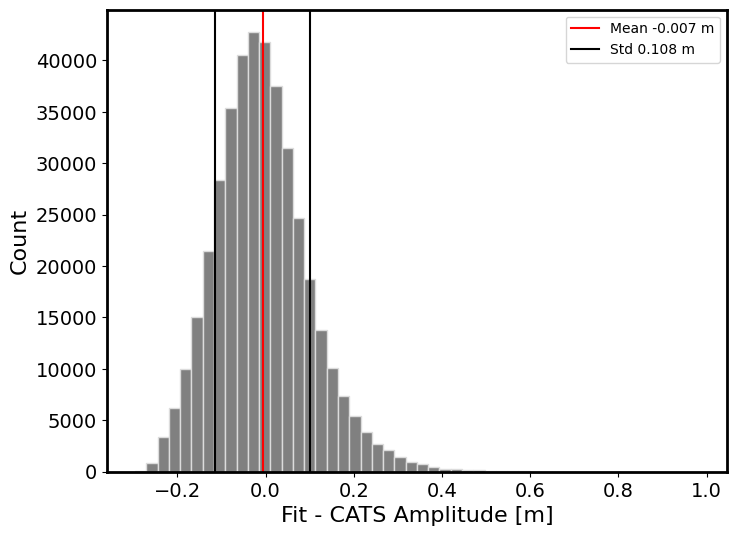

In [ ]:
# Histogram of differences
diff_flat = diff.values.ravel()

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(diff_flat, bins=50, color="gray", edgecolor="gainsboro")
ax.set_xlabel("Fit - CATS Amplitude [m]", fontsize=16)
ax.set_ylabel("Count", fontsize=16)

# Mean and std
mean_diff = np.nanmean(diff_flat)
std_diff = np.nanstd(diff_flat)
ax.axvline(mean_diff, color="red", linestyle="-", label=f"Mean {mean_diff:.3f} m")
ax.axvline(
    mean_diff + std_diff, color="black", linestyle="-", label=f"Std {std_diff:.3f} m"
)
ax.axvline(mean_diff - std_diff, color="black", linestyle="-")
ax.legend()
ax.tick_params(labelsize=14)

In [1]:
### DRAFTS ###

[ 59.65011215 110.74970245  59.69811249 115.3913269   60.05446243
  70.34778595  60.49163818  68.50389862  59.61884308  70.48281097
  59.57480621  67.4151535   59.2271843   67.69391632  59.98039627
  59.70610046  75.73812103  59.92523575  59.26828766  59.70161438
  60.61361694  60.82316971  60.0341835   59.9451828   67.53604126]
Using pixel 864539
864539


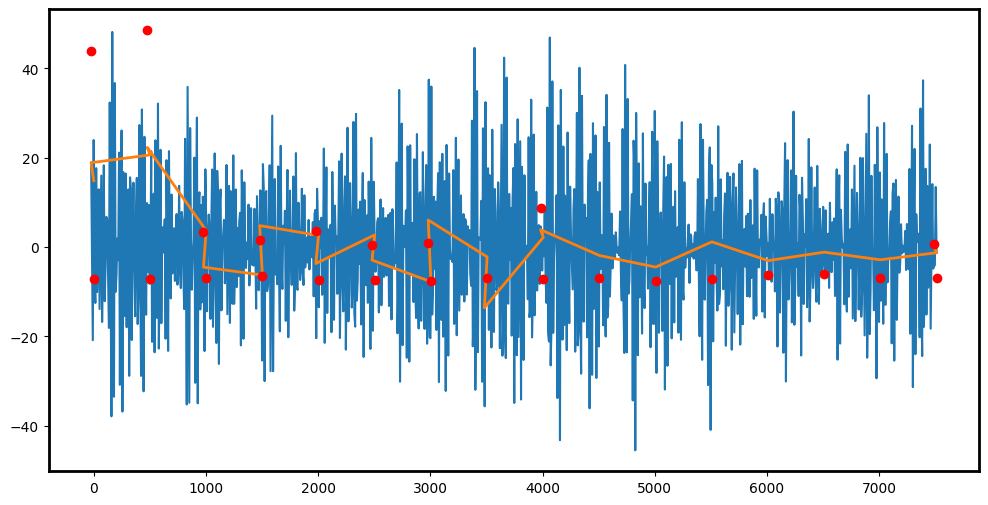

In [88]:
# INDIVIDUAL POINT TESTING
N = Y.shape[1]
T, K = X.shape

beta = np.full(K, np.nan)

for i in range(N):
    y = Y[:, i]

    valid = np.isfinite(y)

    if np.sum(valid) < 20:
        continue

    Xi = X[valid, :]
    yi = y[valid]

    beta, *_ = np.linalg.lstsq(Xi, yi, rcond=None)
    print(yi)
    print(f"Using pixel {i}")
    break  # <-- STOP after first valid pixel
# Y is (time, pixels)
valid_time_counts = np.sum(np.isfinite(Y), axis=0)  # (pixels,)

# Pixels with enough valid data
valid_pixels = np.where(valid_time_counts >= 20)[0]
i = valid_pixels[0]  # or any index you want
print(i)
y = Y[:, i]
y = y - np.nanmean(y)  # Demean to improve fit

valid = np.isfinite(y)
Xi = X[valid, :]
yi = y[valid]
beta, *_ = np.linalg.lstsq(Xi, yi, rcond=None)
y_fit = X @ beta  # (time,)

# Also compute full sinusoid fit and plot
t_sins = np.linspace(t_hours.min(), t_hours.max(), 1000)
X_sins = np.hstack([np.cos(t_sins[:, None] * omega), np.sin(t_sins[:, None] * omega)])
y_sins = X_sins @ beta

plt.figure(figsize=(12, 6))
plt.plot(t_sins, y_sins, label="Sinusoid Fit")
plt.scatter(t_hours, y, marker="o", label="Data", color="red", zorder=5)
plt.plot(t_hours, y_fit, "-", label="Fit", linewidth=2)

In [ ]:
# Harmonic analysis at each point
# Try sinusoid fit MATRIX

# Tidal constituents [hr]
HR_IN_DAY = 24
SEC_IN_HR = 3600

M2 = 12.4206012
S2 = 12
N2 = 12.65834751
K2 = 11.96723606

K1 = 23.9344721
O1 = 25.81933871
P1 = 24.06588766
Q1 = 26.868350

constituents = {
    "M2": M2,
    "S2": S2,
    "N2": N2,
    "K2": K2,
    "K1": K1,
    "O1": O1,
    "P1": P1,
    "Q1": Q1,
}


periods = [constituents[c] for c in constituents]

initial_guess = [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
amp_grid = np.full((ny, nx, 8), np.nan)
ph_grid = np.full((ny, nx, 8), np.nan)

times = np.array(ds_out.time.values, dtype="datetime64[ns]")
t_hours = (times - times[0]) / np.timedelta64(1, "h")

periods = np.array([M2, S2, N2, K2, K1, O1, P1, Q1])
omega = 2 * np.pi / periods

# Design matrix
t_col = t_hours[:, None]  # (time, 1)

X = np.hstack([np.cos(t_col * omega), np.sin(t_col * omega)])

# This has lots of nans, need to mask
# Each row now has different shape...
wse = ds_out.wse.values  # (y, x, time)

ny, nx, nt = wse.shape

# reshape to (space, time)
Y = wse.reshape(ny * nx, nt).T  # (time, n_points)
beta, *_ = np.linalg.lstsq(X, Y, rcond=None)